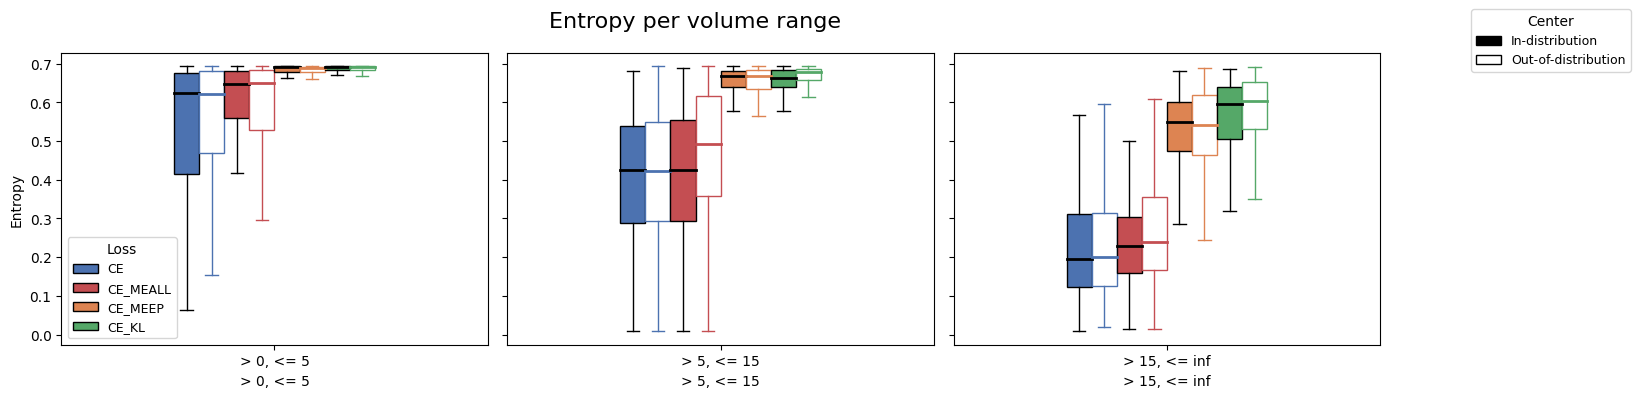

In [1]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule
from notebooks.utils.metrics_utils import * # Imports plt, sns, pd, np

from scipy.stats import pearsonr, spearmanr # Added spearmanr

# Font sizes (inspired by fig2 for consistency)
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# Apply global font settings (adapted from fig2, theme-neutral)
plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)       # Default title size for axes
plt.rc('xtick', labelsize=SMALL_SIZE)      # Default X tick label size
plt.rc('ytick', labelsize=SMALL_SIZE)      # Default Y tick label size
plt.rc('legend', fontsize=SMALL_SIZE)      # Default legend font size
plt.rc('figure', titlesize=BIGGER_SIZE)    # Default figure title size (e.g., for suptitle)


data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}  # Group for plot
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)
    
plot_data = {
'centers_train': centers_train,
'runs_to_compare': runs_to_compare,
'centers_test': centers_test,
'test_splits': test_splits,
'losses': losses,
}

subjs = [pths for pths in test_splits.values()]

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk

# ensure entropy() and get_gt_paths() are defined elsewhere

def entropy_volume_ranges(data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train, runs_to_compare, centers_test, test_splits, losses = data.values()

    rename_centers = {'UtAmSi': 'In-distribution',
                      'UMCL':   'Out-of-distribution'}
    loss_order = ['CE','CE_MEALL','CE_MEEP','CE_KL']
    loss_colors = {
        'CE':      '#4C72B0',
        'CE_MEALL':'#C44E52',
        'CE_MEEP': '#DD8452',
        'CE_KL':   '#55A868'
    }

    # 1) collect entropies per (loss, center, volume-range)
    plot_dict = {
        loss: {c: {f"> {l}, <= {u}": [] for (l,u) in volume_ranges}
               for c in centers_test}
        for loss in losses
    }

    for tr in centers_train:
        for loss in losses:
            run_name = runs_to_compare.get(f"{loss} {tr}")
            for ts in centers_test:
                for subj in get_gt_paths(test_splits[ts]):
                    pred = sitk.ReadImage(
                        os.path.join(subj, f'pred_wmh_softmax_{run_name}.nii.gz')
                    )
                    arr = sitk.GetArrayFromImage(pred)
                    hard = arr.argmax(axis=0)
                    cc = sitk.RelabelComponent(
                        sitk.ConnectedComponent(
                            sitk.GetImageFromArray((hard>0).astype(np.uint8))
                        )
                    )
                    maxlabel = sitk.GetArrayFromImage(cc).max()
                    for lbl in range(1, maxlabel+1):
                        mask = sitk.GetArrayFromImage(cc==lbl).flatten()
                        pts = np.where(mask)[0]
                        vol = len(pts) * np.prod(pred.GetSpacing())
                        probs = arr.flatten()[pts]
                        ent = entropy(probs, apply_mean=True)
                        for (low,high), label in zip(volume_ranges, plot_dict[loss][ts]):
                            if low < vol <= high:
                                plot_dict[loss][ts][label].append(ent)
                                break

    # 2) build DataFrame
    rows = []
    for loss in loss_order:
        for ts in centers_test:
            for vr, ents in plot_dict[loss][ts].items():
                for e in ents:
                    rows.append((loss,
                                 rename_centers[ts],
                                 vr,
                                 e))
    df = pd.DataFrame(rows, columns=['Loss','Center','Volume Range','Entropy'])

    # 3) plot with matplotlib: one subplot per volume-range
    vol_labels = df['Volume Range'].unique()
    n_losses = len(loss_order)
    w = 0.1
    offsets = (np.arange(n_losses*2) - (n_losses*2-1)/2) * w
    offset_map = {}
    for i, loss in enumerate(loss_order):
        offset_map[(loss, 'In-distribution')]   = offsets[2*i]
        offset_map[(loss, 'Out-of-distribution')] = offsets[2*i+1]

    fig, axes = plt.subplots(1, len(vol_labels), figsize=(14,4), sharey=True)
    for ax, vr in zip(axes, vol_labels):
        vrdf = df[df['Volume Range']==vr]
        for loss in loss_order:
            for center in ['In-distribution','Out-of-distribution']:
                ents = vrdf[(vrdf['Loss']==loss) & (vrdf['Center']==center)]['Entropy']
                xpos = offset_map[(loss, center)]
                # style
                if center == 'In-distribution':
                    boxprops = dict(facecolor=loss_colors[loss], edgecolor='black')
                else:
                    boxprops = dict(facecolor='white', edgecolor=loss_colors[loss])
                ax.boxplot(
                    ents,
                    positions=[xpos],
                    widths=w,
                    patch_artist=True,
                    showfliers=False,
                    boxprops=boxprops,
                    whiskerprops=dict(color=boxprops['edgecolor']),
                    capprops=dict(color=boxprops['edgecolor']),
                    medianprops=dict(color=boxprops['edgecolor'], linewidth=2)
                )
        # x-axis label as volume range
        ax.set_xticks([0])
        ax.set_xticklabels([vr], rotation=0)
        ax.set_xlabel(vr)
        if ax is axes[0]:
            ax.set_ylabel('Entropy')

    # Loss legend: filled color patches
    loss_patches = [
        mpatches.Patch(facecolor=loss_colors[l], edgecolor='black', label=f'{l}')
        for l in loss_order
    ]
    axes[0].legend(handles=loss_patches, title='Loss', loc='lower left', fontsize=9)

    # Center legend: fill style
    center_patches = [
        mpatches.Patch(facecolor='black',   edgecolor='black',   label='In-distribution'),
        mpatches.Patch(facecolor='white',   edgecolor='black',   label='Out-of-distribution')
    ]
    fig.legend(handles=center_patches,
               title='Center',
               bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)

    fig.suptitle('Entropy per volume range', fontsize=16)
    plt.subplots_adjust(wspace=0.3)
    plt.tight_layout()
    plt.show()

entropy_volume_ranges(plot_data)

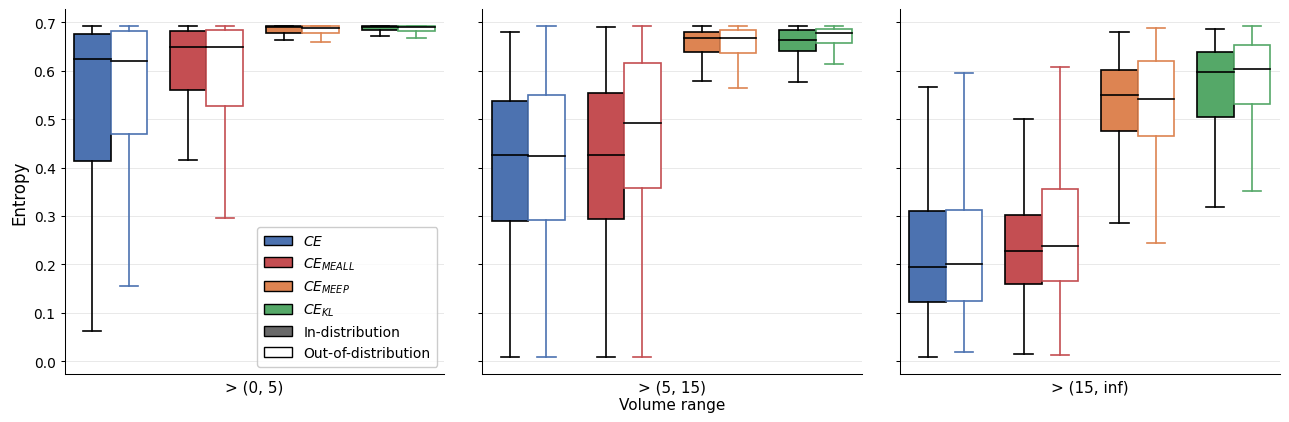

In [6]:
import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))

from src.datamodules import WMHDataModule
# Assuming these utils import plt, pd, np and define entropy, get_gt_paths
# Make sure to have: import matplotlib.pyplot as plt, import pandas as pd, import numpy as np
from notebooks.utils.metrics_utils import *
from scipy.stats import pearsonr, spearmanr

import matplotlib.patches as mpatches
import SimpleITK as sitk
import numpy as np # Ensure numpy is explicitly available
import pandas as pd # Ensure pandas is explicitly available
import matplotlib.pyplot as plt # Ensure pyplot is explicitly available


SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)
plt.rcParams['text.usetex'] = False

data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
# Initial list of test centers, will be modified
current_centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}

losses_config = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

test_splits = {}
for center_name_loop in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center_name_loop}', [.7, .1, .2], seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center_name_loop] = ts_spl

test_splits['UMCL'] = WMHDataModule(data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

# Correctly modify current_centers_test and test_splits for grouped centers
processed_centers_for_grouping = set()
for key, val_list in group_test.items():
    test_splits[key] = []
    for center_name_loop_inner in val_list:
        if center_name_loop_inner in test_splits:
            test_splits[key].extend(test_splits[center_name_loop_inner])
            del test_splits[center_name_loop_inner]
        processed_centers_for_grouping.add(center_name_loop_inner)
    
    current_centers_test = [c for c in current_centers_test if c not in processed_centers_for_grouping]
    current_centers_test.append(key)

plot_data = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': current_centers_test, # Use the modified list
    'test_splits': test_splits,
    'losses': losses_config,
}

# Dummy entropy and get_gt_paths for standalone execution if not available from utils
if 'entropy' not in globals():
    def entropy(p_array, apply_mean=True): # Renamed p to p_array to avoid conflict
        p_array = np.asarray(p_array)
        p_array = np.clip(p_array, 1e-10, 1.0 - 1e-10)
        ent_values = -p_array * np.log2(p_array) - (1-p_array) * np.log2(1-p_array)
        if apply_mean:
            return np.mean(ent_values) if len(ent_values) > 0 else np.nan
        return ent_values if len(ent_values) > 0 else np.array([])


if 'get_gt_paths' not in globals():
    def get_gt_paths(split_data_arg): # Renamed split_data to split_data_arg
        # This is a placeholder. Replace with your actual get_gt_paths implementation.
        # It should return a list of directory paths for subjects.
        # print(f"Warning: Using DUMMY get_gt_paths for split_data: {split_data_arg}")
        return []


def entropy_volume_ranges(data,
                          volume_ranges=((0, 5), (5, 15), (15, np.inf))):
    centers_train_arg, runs_to_compare_arg, centers_test_arg, test_splits_arg, losses_from_data = data.values()

    rename_centers_func = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}
    loss_order = ['CE', 'CE_MEALL', 'CE_MEEP', 'CE_KL']
    loss_colors = {
        'CE': '#4C72B0', 'CE_MEALL': '#C44E52',
        'CE_MEEP': '#DD8452', 'CE_KL': '#55A868'
    }

    plot_dict = {
        loss: {c: {f"> {l, u}": [] for (l, u) in volume_ranges}
               for c in centers_test_arg}
        for loss in loss_order
    }

    for tr in centers_train_arg:
        for loss_name in loss_order:
            run_id_key = f"{loss_name} {tr}"
            run_name = runs_to_compare_arg.get(run_id_key)
            if not run_name: continue
            for ts in centers_test_arg:
                if ts not in test_splits_arg: continue
                for subj_path in get_gt_paths(test_splits_arg[ts]):
                    pred_file = os.path.join(subj_path, f'pred_wmh_softmax_{run_name}.nii.gz')
                    if not os.path.exists(pred_file): continue
                    try:
                        pred = sitk.ReadImage(pred_file)
                        arr = sitk.GetArrayFromImage(pred)
                        if arr.ndim == pred.GetDimension() and arr.shape[0] !=2 : # Single channel, not 2-channel softmax
                             if arr.ndim == 3: arr = arr[np.newaxis, :, :, :]
                             elif arr.ndim == 2: arr = arr[np.newaxis, :, :]
                             if arr.shape[0] == 1: # P(class_1)
                                 arr = np.stack([1.0 - arr[0], arr[0]], axis=0)
                        
                        if arr.shape[0] != 2 : # Expect 2 channels for softmax
                            # print(f"Warning: Softmax prediction {pred_file} does not have 2 channels. Shape: {arr.shape}")
                            continue

                        hard = arr.argmax(axis=0)
                        img_for_cc_data = (hard > 0).astype(np.uint8)
                        img_for_cc = sitk.GetImageFromArray(img_for_cc_data)
                        original_spacing = pred.GetSpacing()
                        current_dim = img_for_cc.GetDimension()
                        if current_dim <= len(original_spacing):
                            img_for_cc.SetSpacing(original_spacing[:current_dim])
                        else:
                            img_for_cc.SetSpacing([1.0]*current_dim)

                        cc_filter = sitk.ConnectedComponentImageFilter()
                        cc = cc_filter.Execute(img_for_cc)
                        cc = sitk.RelabelComponent(cc)
                        maxlabel = sitk.GetArrayFromImage(cc).max()

                        for lbl in range(1, maxlabel + 1):
                            lesion_mask_img = (cc == lbl)
                            lesion_mask_arr_flat = sitk.GetArrayFromImage(lesion_mask_img).flatten().astype(bool)
                            if not lesion_mask_arr_flat.any(): continue
                            vol = lesion_mask_arr_flat.sum() * np.prod(img_for_cc.GetSpacing())
                            
                            probs_positive_class_all = arr[1].flatten()
                            if len(lesion_mask_arr_flat) != len(probs_positive_class_all): continue
                            probs_in_component = probs_positive_class_all[lesion_mask_arr_flat]
                            if len(probs_in_component) == 0: continue
                            
                            ent = entropy(probs_in_component, apply_mean=True)
                            if np.isnan(ent): continue

                            for (low, high), label_vr in zip(volume_ranges, plot_dict[loss_name][ts]):
                                if low < vol <= high:
                                    plot_dict[loss_name][ts][label_vr].append(ent)
                                    break
                    except Exception: # Basic catch-all for robustness during data processing
                        # print(f"Error processing subject {subj_path} for {run_name}: {e_inner}")
                        continue
    rows = []
    for loss_name_df in loss_order:
        if loss_name_df not in plot_dict: continue
        for ts in centers_test_arg:
            if ts not in plot_dict[loss_name_df]: continue
            for vr_label, ents_list in plot_dict[loss_name_df][ts].items(): # Renamed vr to vr_label, ents to ents_list
                for e_val in ents_list:
                    rows.append((loss_name_df, rename_centers_func.get(ts, ts), vr_label, e_val))
    df = pd.DataFrame(rows, columns=['Loss', 'Center', 'Volume Range', 'Entropy'])

    if df.empty:
        print("DataFrame is empty, cannot generate plot.")
        return

    vol_labels = df['Volume Range'].unique()
    if not vol_labels.any():
        print("No volume ranges with data to plot.")
        return

    n_losses = len(loss_order)
    # Positions for the center of each loss group (e.g., CE, CE_MEALL)
    loss_group_centers_x = np.arange(n_losses)
    
    # Width of a single boxplot (In or Out)
    single_box_width = 0.38 # Increase for tighter look, ensure it's less than 0.5 for distinct groups at 0,1,2,3
    
    # No gap between In and Out for the same loss: position them adjacent.
    # In-dist box will be centered at: loss_group_center - single_box_width / 2
    # Out-dist box will be centered at: loss_group_center + single_box_width / 2

    fig, axes = plt.subplots(1, len(vol_labels),
                             figsize=(4.5 * len(vol_labels), 5), # Adjusted figsize for consistency
                             sharey=True)
    if len(vol_labels) == 1:  # Handle case of single subplot
        axes = [axes]

    for ax_idx, vr in enumerate(vol_labels):
        ax = axes[ax_idx]
        vrdf = df[df['Volume Range'] == vr]
        
        plotted_something_in_ax = False
        min_x_plotted, max_x_plotted = float('inf'), float('-inf')

        for i, loss_name_plot in enumerate(loss_order):
            base_pos = loss_group_centers_x[i]
            
            pos_in = base_pos - single_box_width / 2
            ents_in = vrdf[(vrdf['Loss'] == loss_name_plot) & (vrdf['Center'] == 'In-distribution')]['Entropy']
            if not ents_in.empty:
                plotted_something_in_ax = True
                min_x_plotted = min(min_x_plotted, pos_in - single_box_width/2)
                max_x_plotted = max(max_x_plotted, pos_in + single_box_width/2)
                ax.boxplot(
                    ents_in, positions=[pos_in], widths=single_box_width, patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor=loss_colors.get(loss_name_plot, '#CCCCCC'), edgecolor='black', linewidth=1.2),
                    whiskerprops=dict(color='black', linewidth=1.2),
                    capprops=dict(color='black', linewidth=1.2),
                    medianprops=dict(color='black', linewidth=1.2)
                )

            pos_out = base_pos + single_box_width / 2
            ents_out = vrdf[(vrdf['Loss'] == loss_name_plot) & (vrdf['Center'] == 'Out-of-distribution')]['Entropy']
            if not ents_out.empty:
                plotted_something_in_ax = True
                min_x_plotted = min(min_x_plotted, pos_out - single_box_width/2)
                max_x_plotted = max(max_x_plotted, pos_out + single_box_width/2)
                ax.boxplot(
                    ents_out, positions=[pos_out], widths=single_box_width, patch_artist=True, showfliers=False,
                    boxprops=dict(facecolor='white', edgecolor=loss_colors.get(loss_name_plot, '#CCCCCC'), linewidth=1.2),
                    whiskerprops=dict(color=loss_colors.get(loss_name_plot, '#CCCCCC'), linewidth=1.2),
                    capprops=dict(color=loss_colors.get(loss_name_plot, '#CCCCCC'), linewidth=1.2),
                    medianprops=dict(color='black', linewidth=1.2)
                )
        
        # X-axis: No ticks/labels for losses, just the volume range label below.
        ax.set_xticks([])
        ax.set_xticklabels([])
        
        # Determine middle index for x-axis labeling
        middle_idx = len(vol_labels) // 2
        
        if ax_idx == middle_idx:
            # For the middle subplot, add "Volume range" below the vr label
            ax.set_xlabel(f"{vr}\nVolume range", fontsize=MEDIUM_SIZE - 1)
        else:
            # For other subplots, just use the vr label
            ax.set_xlabel(vr, fontsize=MEDIUM_SIZE - 1)

        if plotted_something_in_ax:
            ax.set_xlim(min_x_plotted - 0.1, max_x_plotted + 0.1) # Tight around plotted boxes + small pad
        else: # Fallback
            ax.set_xlim(-single_box_width, (n_losses -1) + single_box_width )


        ax.yaxis.grid(True, linestyle='-', linewidth=0.5, color='lightgrey', alpha=0.7)
        ax.xaxis.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.75)
        ax.spines['bottom'].set_linewidth(0.75)
        ax.tick_params(axis='y', which='major', length=3, width=0.75, labelsize=SMALL_SIZE)
        ax.tick_params(axis='x', length=0) # No length for x ticks as they are hidden


        if ax_idx == 0:
            ax.set_ylabel('Entropy', fontsize=MEDIUM_SIZE)

    # Legend creation
    loss_legend_handles = [
        mpatches.Patch(facecolor=loss_colors.get(l, '#CCCCCC'), edgecolor='black',
                       label=fr"${l.replace('_', '_{')}{'}' if '_' in l else ''}$")
        for l in loss_order
    ]
    dist_legend_handles = [
        mpatches.Patch(facecolor='dimgrey', edgecolor='black', label='In-distribution'),
        mpatches.Patch(facecolor='white', edgecolor='black', label='Out-of-distribution')
    ]
    combined_handles = loss_legend_handles + dist_legend_handles

    if len(axes) > 0: # Place legend in the first subplot
        axes[0].legend(handles=combined_handles, loc='best', # Changed loc to 'best'
                       fontsize=SMALL_SIZE, ncol=1, frameon=True,  # Changed fontsize and ncol
                       fancybox=True, edgecolor='silver', borderpad=0.5)

    # fig.suptitle('Entropy per Volume Range of Predicted Lesions', fontsize=BIGGER_SIZE, y=0.97)
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.15, wspace=0.1) # wspace reduced

    # Save the figure
    output_dir = 'notebooks/main/figs/pdfs/'
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, 'Figure6.pdf')
    plt.savefig(file_path, format='pdf', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()

# Assuming plot_data is defined globally and correctly
entropy_volume_ranges(plot_data)